# MFIS $_{t-1}$ + DMO $_{t}\rightarrow$ MFIS $_t$

In [27]:
from src.patient_data_dispatcher import PatientDataDispatcher
from src.core.enums import MileStone, DataFrequency, PatientDataType
from src.pipeline import dmo_for_random_forest
from src.model import DMORandomForestRegressor
from src.evaluation import Evaluation

import torch

In [28]:
dmo_features = [
    "wb_all_sum",
    "walkdur_all_sum",
    "wbsteps_all_sum",
    "wbdur_all_avg",
    "wbdur_all_p90",
    "wbdur_all_var",
    "cadence_all_avg",
    "strdur_all_avg",
    "cadence_all_var",
    "strdur_all_var",
    "ws_1030_avg",
    "strlen_1030_avg",
    "wb_10_sum",
    "ws_10_p90",
    "wb_30_sum",
    "ws_30_avg",
    "strlen_30_avg",
    "cadence_30_avg",
    "strdur_30_avg",
    "ws_30_p90",
    "cadence_30_p90",
    "ws_30_var",
    "strlen_30_var",
    "wb_60_sum",
    "total_worn_h",
]

In [29]:
pdd = PatientDataDispatcher(
    "config/config.yaml",
    dmo_features,
    MileStone.ALL,
    data_frequency=DataFrequency.DAILY,
    physical_subset=True,
    #static_features=static_features
)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [30]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# perform impute on a visit by visit basis, as some visits are completely missing
imputer = IterativeImputer(missing_values=-1, tol=1e-2, keep_empty_features=True)
patients, visits, features, days = dmo_data.shape

for p in range(patients):
    for v in range(visits):
        visit_data = dmo_data[p, v]

        if (visit_data == -1).all():
            continue

        dmo_data[p, v] = torch.from_numpy(imputer.fit_transform(visit_data)).to(dtype=torch.float64)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [31]:
dmo_data.shape

torch.Size([597, 5, 7, 25])

In [32]:
# remove missing labels
patient_indexs = []
patient, visit, day, features = dmo_data.shape
for p in range(patient):
    all_visits = True
    for v in range(visit):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

dmo_data = dmo_data[patient_indexs]
dmo_labels = dmo_labels[patient_indexs]

In [33]:
fatigue_value = dmo_labels.flatten(start_dim=1, end_dim=2)

In [34]:
fatigue_value.shape

torch.Size([280, 5])

In [35]:
fatigue_input = fatigue_value[:, :-1]
fatigue_input = fatigue_input.unsqueeze(dim=2)
fatigue_input = fatigue_input.flatten(start_dim=0, end_dim=1)
fatigue_input.shape

torch.Size([1120, 1])

In [36]:
dmo_data = dmo_data.mean(axis=2)
dmo_data = dmo_data[:, 1:]
dmo_data = dmo_data.flatten(start_dim=0, end_dim=1)

dmo_data.shape

torch.Size([1120, 25])

In [37]:
dmo_fatigue_input = torch.concatenate((dmo_data, fatigue_input), dim=1)
dmo_fatigue_input.shape

torch.Size([1120, 26])

In [38]:
fatigue_label = fatigue_value[:, 1:]
fatigue_label = fatigue_label.flatten(start_dim=0, end_dim=1)
fatigue_label.shape

torch.Size([1120])

In [39]:
transforms = (None, None)
train, test = dmo_for_random_forest(dmo_fatigue_input, fatigue_label, transforms, normalise=False)

train_input, train_label = train
test_input, test_label = test

In [40]:
rf_model = DMORandomForestRegressor(n_trees=500)

rf_model.train(train_input, train_label)
score = rf_model.score(test_input, test_label)
print(score)

0.5302792696829604


{'accuracy': 0.004464285714285714, 'Mean Squared Error': 34.60176086425781, 'Mean Absolute Error': 4.623419761657715, 'R^2': 0.5302792220270777}


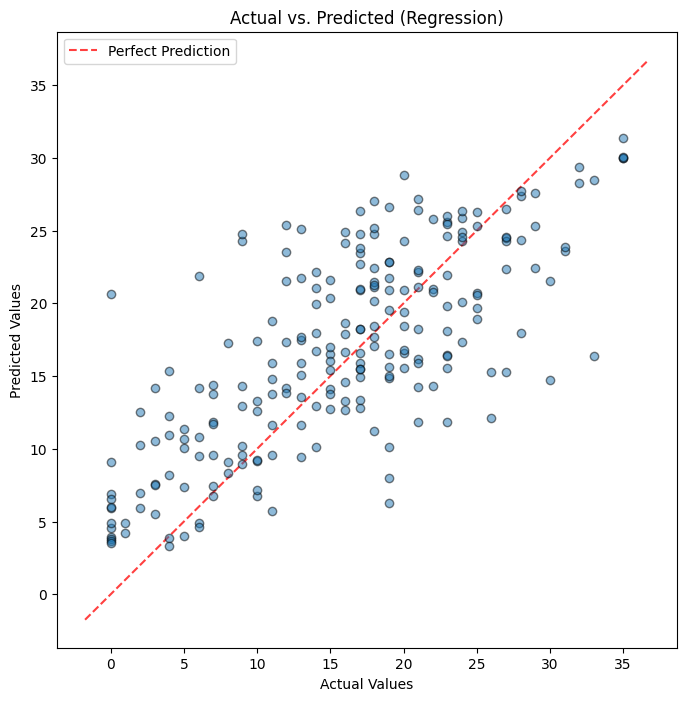

In [41]:
prediction = torch.tensor(rf_model.predict(test_input))
actual = test_label
evaluation = Evaluation(prediction, actual)
print(evaluation.compute_all_metrics())
evaluation.evaluation_plot().show()

['wb_all_sum', 'walkdur_all_sum', 'wbsteps_all_sum', 'wbdur_all_avg', 'wbdur_all_p90', 'wbdur_all_var', 'cadence_all_avg', 'strdur_all_avg', 'cadence_all_var', 'strdur_all_var', 'ws_1030_avg', 'strlen_1030_avg', 'wb_10_sum', 'ws_10_p90', 'wb_30_sum', 'ws_30_avg', 'strlen_30_avg', 'cadence_30_avg', 'strdur_30_avg', 'ws_30_p90', 'cadence_30_p90', 'ws_30_var', 'strlen_30_var', 'wb_60_sum', 'total_worn_h', 'prev MFIS']


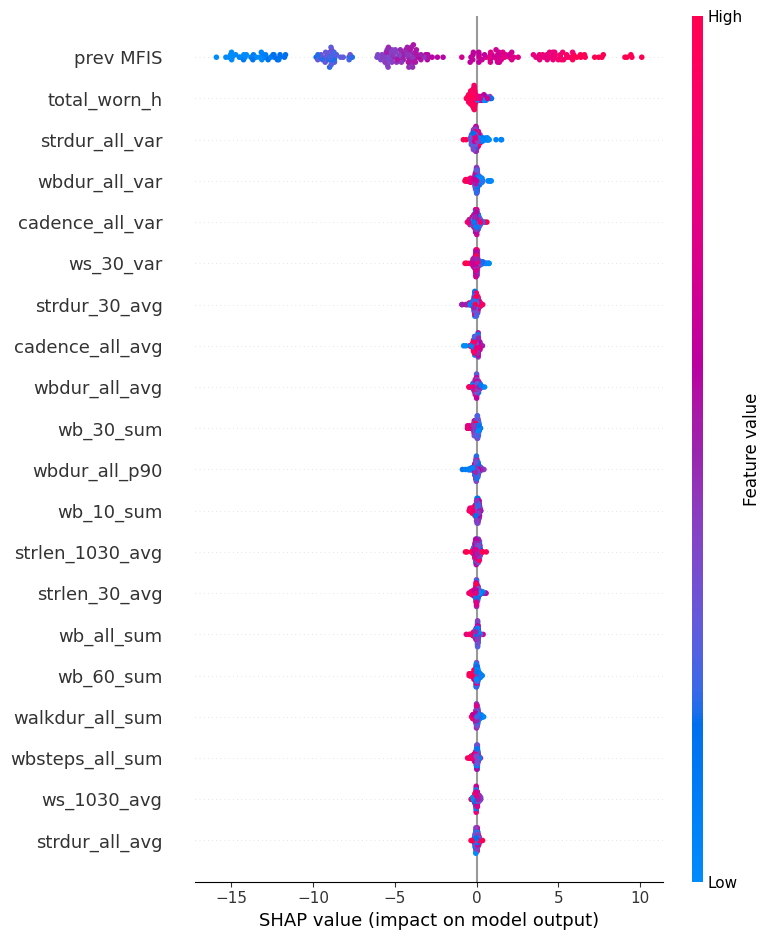

In [42]:
import shap

dmo_features += ["prev MFIS"]
features = dmo_features
print(features)

random_forest_model = rf_model.random_forest
test_input_numpy = torch.Tensor.numpy(test_input)

explainer = shap.TreeExplainer(random_forest_model)
shap_values = explainer.shap_values(test_input_numpy)
shap.summary_plot(
    shap_values,
    test_input_numpy,
    feature_names=features ,
)

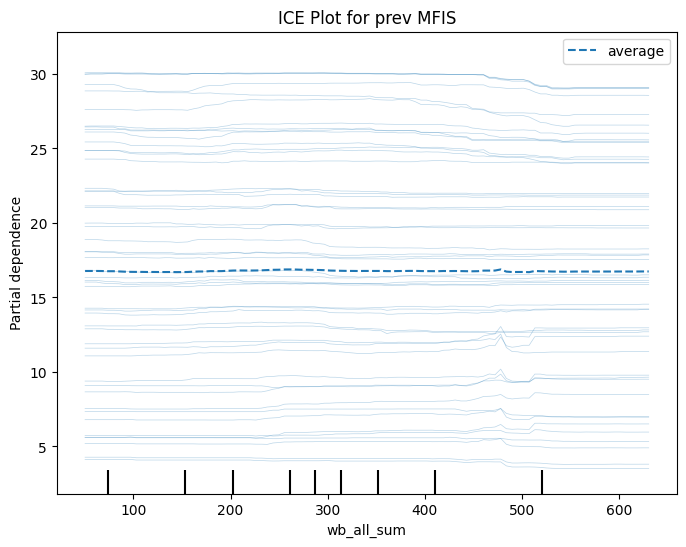

In [43]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

feature_index = 0

test_numpy = test_input.numpy()

fig, ax = plt.subplots(figsize=(8, 6))

display = PartialDependenceDisplay.from_estimator(
    random_forest_model, 
    test_numpy, 
    features=[feature_index],
    feature_names=dmo_features,
    kind='both', 
    subsample=50,
    ax=ax
)

ax.set_title("ICE Plot for prev MFIS")
plt.show()